In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import pyneb as pn
from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

import numpy as np
import matplotlib.pyplot as plt
import astropy
from astropy.io import fits
from scipy.interpolate import Akima1DInterpolator
from scipy import optimize as opt
import sys
import emcee
import numpy as np
from scipy.optimize import curve_fit
from astropy.table import Table
import astropy.units as u
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np
from astropy.io import fits
import time
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
from scipy import signal
import matplotlib.pyplot as plt
import warnings
import pandas as pd

In [37]:
RUBIES_and_CEERS_table = Table.read('MAIN_CORRECTED_RUBIES_AND_CEERS_TABLE.fits')
source_name = RUBIES_and_CEERS_table['filename']
flux = RUBIES_and_CEERS_table['flux']
obs_wavelength = RUBIES_and_CEERS_table['wavelength']
RUBIES_and_CEERS_table

index,filename,wavelength,flux,flux_error,flux_lambda,flux_error_lambda,obs_wavelength_in_ang,catalog,redshift,ra,dec,flags
int64,bytes72,object,object,object,object,object,object,bytes6,float64,float64,float64,bool
0,hlsp_ceers_jwst_nirspec_nirspec10-000023_comb-mgrat_v0.7_x1d-masked.fits,[0.96244768 0.9630861 0.96372452 ... 5.28243303 5.28422525 5.28601747],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],[ 9624.47676976 9630.86099814 9637.24521939 ... 52824.33025023\n 52842.25250749 52860.17467402],CEERS,9.221132981885157,214.901252,52.846997,True
1,hlsp_ceers_jwst_nirspec_nirspec10-000024_comb-mgrat_v0.7_x1d-masked.fits,[0.96250468 0.96314332 0.96378196 ... 5.28221363 5.28400721 5.28580077],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],[ 9625.04683996 9631.43319956 9637.81955463 ... 52822.13634886\n 52840.07206128 52858.00768795],CEERS,6.702671875330433,214.897232,52.843854,True
2,hlsp_ceers_jwst_nirspec_nirspec10-000515_comb-mgrat_v0.7_x1d-masked.fits,[0.96289443 0.96353188 0.96416933 ... 5.2825265 5.28430936 5.28609219],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],[ 9628.94432129 9635.31881 9641.69327284 ... 52825.26503233\n 52843.09356309 52860.92194739],CEERS,6.6393799882605755,214.878534,52.874142,True
3,hlsp_ceers_jwst_nirspec_nirspec10-000618_comb-mgrat_v0.7_x1d-masked.fits,[0.96233972 0.96297913 0.96361855 ... 5.2831541 5.28495059 5.28674707],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],[ 9623.39716028 9629.79132667 9636.18549103 ... 52831.5409797\n 52849.50589146 52867.47072355],CEERS,6.050465380340398,214.876469,52.839412,False
4,hlsp_ceers_jwst_nirspec_nirspec10-000669_comb-mgrat_v0.7_x1d-masked.fits,[0.96277494 0.96341363 0.96405233 ... 5.28278507 5.28458027 5.28641092],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],[ 9627.74935786 9634.13633204 9640.52330718 ... 52827.85073805\n 52845.80268067 52864.10919306],CEERS,5.274271436464599,214.896381,52.838514,False
5,hlsp_ceers_jwst_nirspec_nirspec10-000672_comb-mgrat_v0.7_x1d-masked.fits,[0.96268285 0.96332172 0.9639606 ... 5.28229041 5.28408762 5.28588481],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],[ 9626.82845864 9633.21721215 9639.60597256 ... 52822.90414043\n 52840.87616004 52858.84810917],CEERS,5.667702110153311,214.889677,52.83297699999999,False
6,hlsp_ceers_jwst_nirspec_nirspec10-001027_comb-mgrat_v0.7_x1d-masked.fits,[0.9626523 0.96329148 0.96393066 ... 5.2831987 5.28499442 5.28679013],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],[ 9626.52296569 9632.91478454 9639.30660097 ... 52831.98696044\n 52849.94415747 52867.90127362],CEERS,7.821691241031335,214.8829941,52.84041590000001,False
7,hlsp_ceers_jwst_nirspec_nirspec10-001207_comb-mgrat_v0.7_x1d-masked.fits,[0.96271158 0.96334681 0.96398204 ... 5.28328586 5.2850752 5.28686452],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],[ 9627.11583726 9633.46809763 9639.8203739 ... 52832.85864509\n 52850.75196398 52868.64521812],CEERS,4.8977519143246875,214.9600055,52.8311713,False
8,hlsp_ceers_jwst_nirspec_nirspec10-001212_comb-mgrat_v0.7_x1d-masked.fits,[0.96221478 0.96285021 0.96348564 ... 5.28334034 5.28513114 5.28692193],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],[ 9622.14776545 9628.5020681 9634.85638996 ... 52833.40339333\n 52851.31139256 52869.21933158],CEERS,5.99575149439616,214.9541475,52.82861319999999,True


In [4]:
#RUBIES_and_CEERS_table = Table.read('MASTER_RUBIES_AND_CEERS_TABLE.fits')
#flux = RUBIES_and_CEERS_table['flux']
# source_name = RUBIES_and_CEERS_table['filename']
# flux_error = RUBIES_and_CEERS_table['flux_error']
# rest_frame = RUBIES_and_CEERS_table['rest_frame_wavelength']
# flags = RUBIES_and_CEERS_table['flags']
# obs_wavelength = RUBIES_and_CEERS_table['wavelength']
# which_catalog = RUBIES_and_CEERS_table['catalog']
# wavelength_ang = RUBIES_and_CEERS_table['obs_wavelength_in_ang']
# flux_lambda = RUBIES_and_CEERS_table['flux_lambda']
# rest_frame_in_ang = RUBIES_and_CEERS_table['rest_frame_wavelength_in_ang']
# flux_lambda_cleaned_for_each_spectra = RUBIES_and_CEERS_table['flux_lambda_cleaned']
# flux_error_lambda_cleaned = RUBIES_and_CEERS_table['flux_error_lambda_cleaned']
# redshift = RUBIES_and_CEERS_table['redshift']
# rest_frame_wavelength_cleaned = RUBIES_and_CEERS_table['rest_frame_wavelength_cleaned']
# obs_wavelength_cleaned = RUBIES_and_CEERS_table['obs_wavelength_cleaned']
# new_redshifts = RUBIES_and_CEERS_table['new_rubies_redshifts'] 

## re-do table with *correct* flux/wavelength

In [249]:
master_file = []
master_wave = []
master_flux = []
master_flux_error = []

for k, filename in enumerate(RUBIES_and_CEERS_table['filename']):
    catalog = RUBIES_and_CEERS_table['catalog'][k]
    base = '../Capstone Project/'
    
    if catalog == 'CEERS':
        if 'nirspec4' in filename:
            base += 'nirspec4/comb-mgrat/'
        elif 'nirspec5' in filename:
            base += 'nirspec5/comb-mgrat/'
        elif 'nirspec7' in filename:
            base += 'nirspec7/comb-mgrat/'
        elif 'nirspec8' in filename:
            base += 'nirspec8/comb-mgrat/'
        elif 'nirspec9' in filename:
            base += 'nirspec9/comb-mgrat/'
        elif 'nirspec10' in filename:
            base += 'nirspec10/comb-mgrat/'
    elif catalog == 'RUBIES':
        base += 'RUBIES/'
    
    full_path = base + filename
    
    data = fits.open(full_path)
    hdu = data[1].data
    wavelength = hdu['WAVELENGTH']
    flux = hdu['FLUX']
    flux_error = hdu['FLUX_ERROR']
    
    master_file.append(filename)
    master_wave.append(wavelength)
    master_flux.append(flux)
    master_flux_error.append(flux_error)

In [44]:
np.where(source_name == 'jw04233006003_CEERS-FULL-V2_F290LP_G395M_s49188_x1d.fits')

(array([261]),)

## checking if new table is *correct*

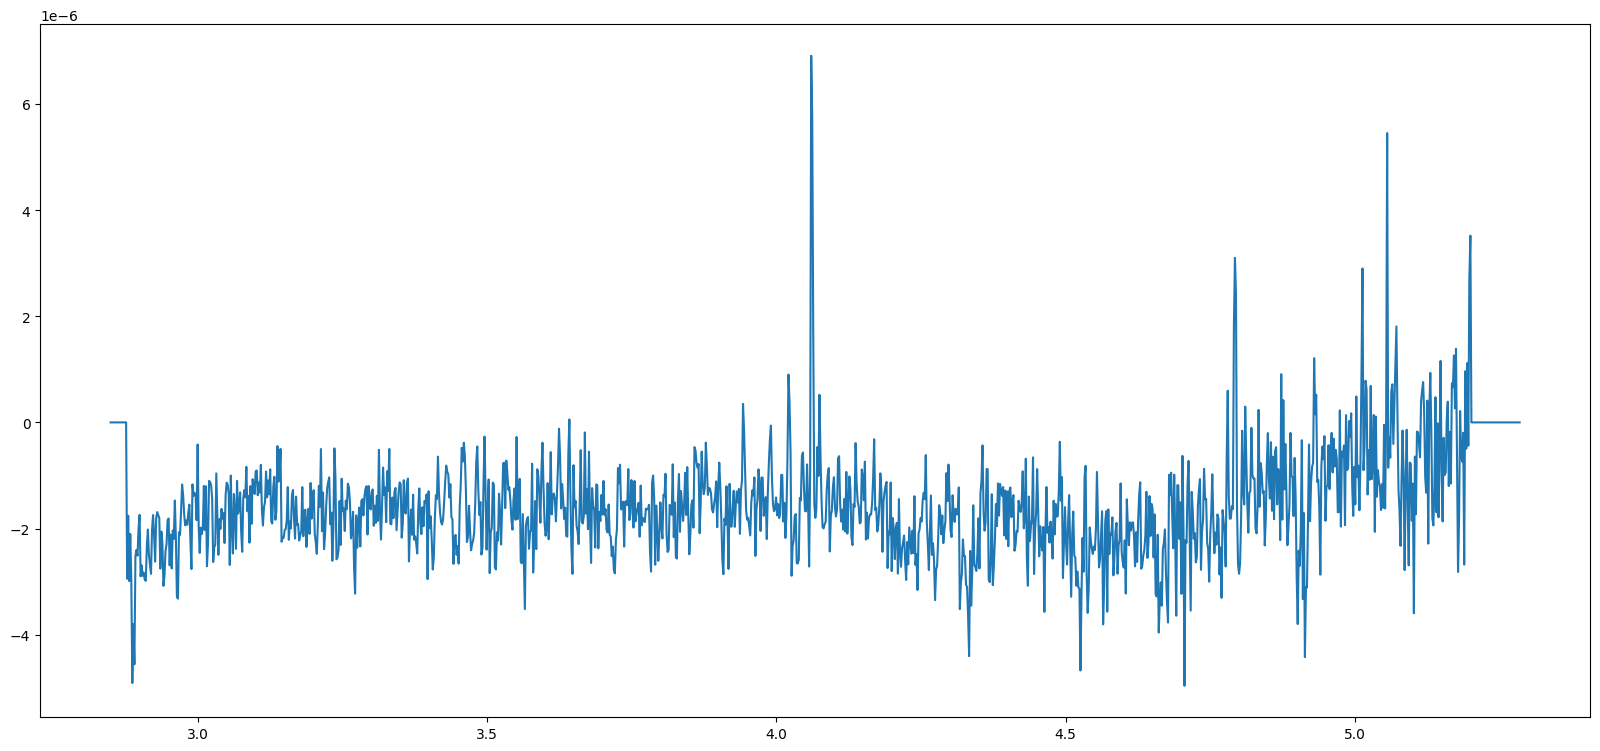

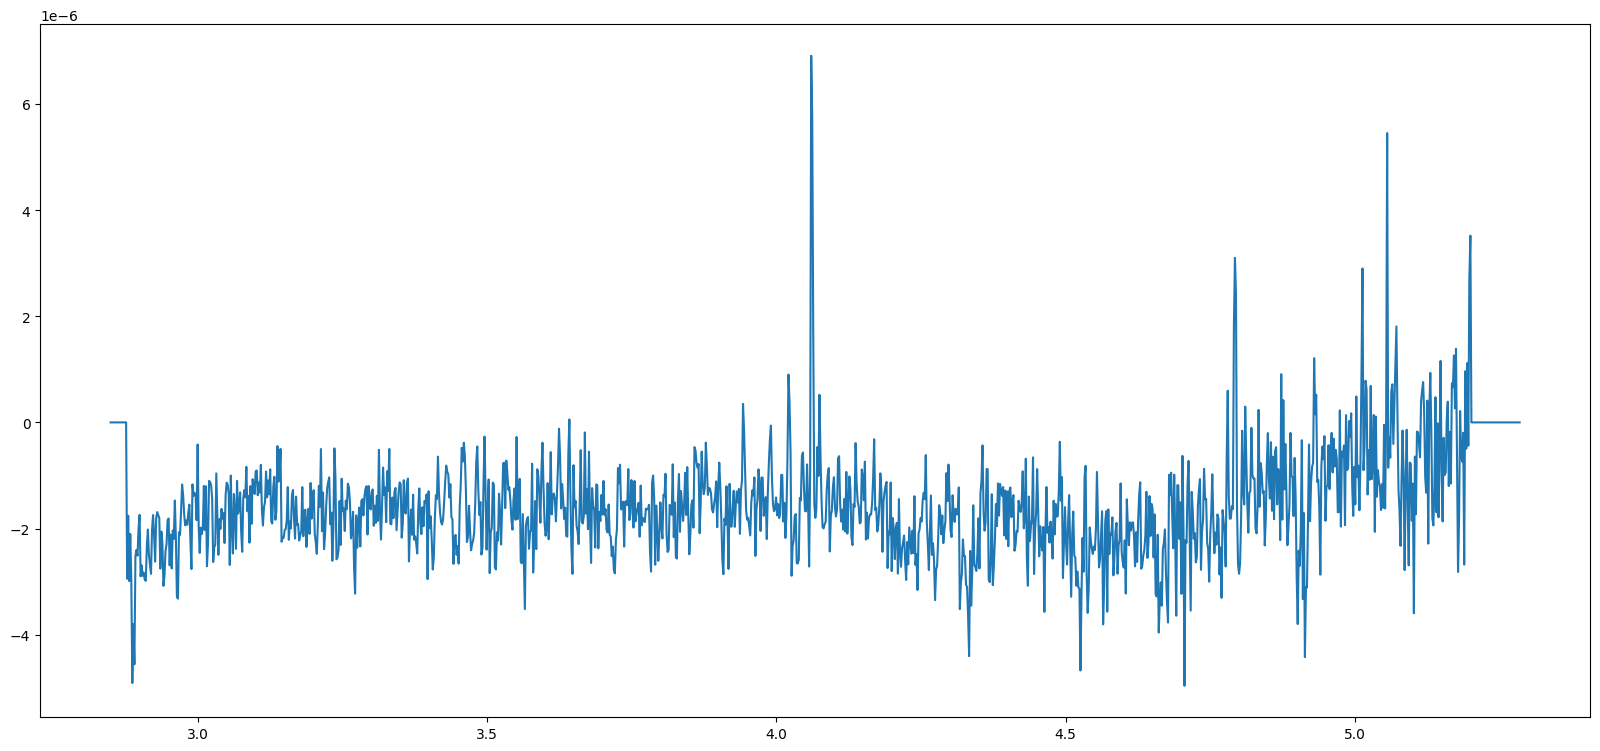

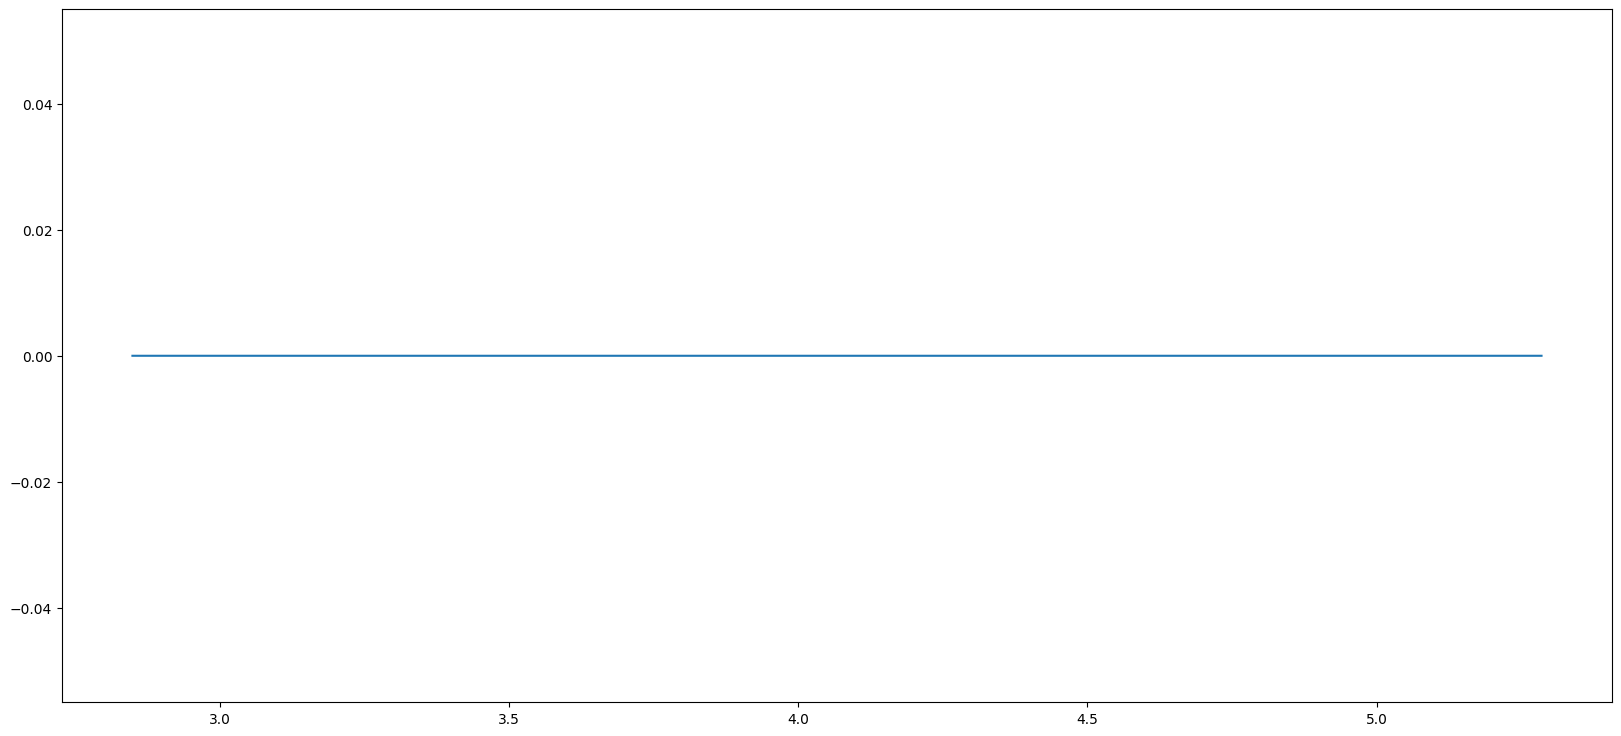

In [45]:
# #print(master_file[50])
# full_path = '../Capstone Project/nirspec5/comb-mgrat/hlsp_ceers_jwst_nirspec_nirspec5-000717_comb-mgrat_v0.7_x1d-masked.fits'
# data = fits.open(full_path)
# hdu = data[1].data
# wavelength = hdu['WAVELENGTH']
# flux = hdu['FLUX']

# plt.figure()
# plt.plot(master_wave[50], master_flux[50])
# plt.figure()
# plt.plot(wavelength, flux)
# plt.show()

#full_path = '../Capstone Project/nirspec10/comb-mgrat/hlsp_ceers_jwst_nirspec_nirspec10-001212_comb-mgrat_v0.7_x1d-masked.fits'
full_path = '../Capstone Project/RUBIES/jw04233006003_CEERS-FULL-V2_F290LP_G395M_s49188_x1d.fits'
data = fits.open(full_path)
hdu = data[1].data
test_wavelength = hdu['WAVELENGTH']
test_flux = hdu['FLUX']

index = 261
RUBIES_and_CEERS_table = Table.read('MAIN_CORRECTED_RUBIES_AND_CEERS_TABLE.fits')
source_name = RUBIES_and_CEERS_table['filename']
flux = RUBIES_and_CEERS_table['flux']
obs_wavelength = RUBIES_and_CEERS_table['wavelength']

plt.figure(figsize=(20,9))
plt.plot(test_wavelength, test_flux)
plt.figure(figsize=(20,9))
plt.plot(obs_wavelength[index], flux[index])
plt.figure(figsize=(20,9))
plt.plot(obs_wavelength[index], flux[index]-test_flux)
plt.show()

In [36]:
RUBIES_and_CEERS_table = Table.read('MAIN_CORRECTED_RUBIES_AND_CEERS_TABLE.fits')
np.where(RUBIES_and_CEERS_table['filename'] == 'jw04233005002_CEERS-FULL-V2_F290LP_G395M_s13944_x1d.fits')

#plt.plot(RUBIES_and_CEERS_table['wavelength'][100], RUBIES_and_CEERS_table['flux'][198])
#RUBIES_and_CEERS_table['flags'][198] = True
#RUBIES_and_CEERS_table.write('MAIN_CORRECTED_RUBIES_AND_CEERS_TABLE.fits',overwrite='True')


(array([198]),)

In [250]:
# t = Table([range(len(master_file)), master_file, master_wave, master_flux,master_flux_error], names=('index', 'filename', 'wavelength', 'flux','flux_error'))
# fits_filename = 'MAIN_CORRECTED_RUBIES_AND_CEERS_TABLE.fits'
# t.write(fits_filename, format='fits', overwrite=True)

In [6]:
h_beta = 4861.333
h_alpha = 6562.819
h_gamma = 4340.1
OIII4960 = 4958.911
OIII5007 = 5006.843
OIII4363 = 4363.210
SII6716 = 6716.440
SII6731 = 6730.810
OII3726= 3726.032
OII3729= 3728.815

In [7]:
def h_beta_sfr(luminosity_h_beta):
    sfr = 2.86 * (luminosity_h_beta / (1.26 * (10**41)) )
    return sfr

def h_alpha_sfr(luminosity_h_alpha):
    sfr =  luminosity_h_alpha / (1.26 * (10**41)) 
    return sfr
#https://iopscience.iop.org/article/10.1086/305588/pdf

def flux_to_luminosity(flux, redshift):
    distance = cosmo.luminosity_distance(redshift).to(u.cm).value
    lum = 4*np.pi * ((distance)**2 ) * flux
    return lum
    #the 4pi comes from the flux and luminsosity astro equation 

In [8]:
def wavelength_exists(array, wavelength):
    #array = eq.cleaned
    #wavelength = halpha or hbeta
    idx = np.where((array > wavelength - 10) & (array < wavelength + 10))
    if len(flux_cleaned[idx]) == 0:
        return False
    else:
        return True

## EMCEE W/ REDUCED CHI SQUARE FITTING

- make massive PDF file of reduced chi square plot + emcee fit
- in the title of each source, save an ID or some way to classify them
- then we can visually inspect each source and just flag the bad ones (i.e. make an array of Trues this way we can just change to False if need be)
- also make a FINAL flux column of both flux_instrinsic (dust_corrected) [ratio > 1] and flux (not dust corrected) [ratio<1]


In [85]:
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Line model including contxainuum
def line(x, b):
    return np.ones(len(x)) * b

def line_model(x, A, mu, sigma, b):
    return gaussian(x, A, mu, sigma) + line(x, b)

def log_likelihood(theta, x, y, yerr):
    model = line_model(x, *theta)
    lnL = -0.5 * np.sum((y - model)**2 / yerr**2)
    return lnL

def log_prior(theta, wave_center, Amp_max):
    A, mu, sigma, b = theta
    left_mu = wave_center - 5
    right_mu = wave_center + 5
    min_A = 0
    max_A = Amp_max * 2
    sigma_window_left = .5
    sigma_window_right = 20
    if (0 < A < max_A) & (left_mu <= mu <= right_mu) & (sigma_window_left <= sigma < sigma_window_right):# & (b > 0):
        return 0.0
    else:
        return -np.inf

def log_probability(theta, x, y, yerr, wave_center, Amp_max):
    lp = log_prior(theta, wave_center, Amp_max)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y, yerr)

# Function to fit the Hα and Hβ lines
def fitting_line(wave, flux, flux_err, line_center, window_wavelength, diagnose=False):
    min_window = line_center - window_wavelength
    max_window = line_center + window_wavelength
    indx = (wave >= min_window) & (wave <= max_window)

    
    spec_window = flux[indx]
    wave_window = wave[indx]
    err_spec_window = flux_err[indx]

    # Initial guess for the curve fit
    guess_A = np.abs(np.max(spec_window))
    guess_mu = line_center
    guess_sigma = 20
    guess_b = np.abs(np.median(spec_window))
    
    low_bounds = [0, min_window, 0, -guess_b]
    high_bounds = [2 * guess_A, max_window, 200, 2 * guess_b]
    popt, _ = curve_fit(line_model, wave_window, spec_window, p0=[guess_A, guess_mu, guess_sigma, guess_b],
                        bounds=(low_bounds, high_bounds))
    if diagnose == True: 
        plotting_code = line_model(wave_window,popt[0],popt[1],popt[2],popt[3])
#         plt.figure()
#         plt.plot(wave_window,plotting_code,c='cadetblue',label='model')
#         plt.plot(wave_window,spec_window,c='purple',label='data')
#         plt.axvline(min_window)
#         plt.axvline(max_window)

#         plt.legend()
#         plt.show()
    fluxes_emcee = popt[0] * popt[2] * np.sqrt(2 * np.pi)
    
   # return fluxes_emcee
    return popt



def emcee_fit(wave, flux, flux_err, line_center, window_wavelength, 
                 diagnose = False,save=True, filename = 'Emcee_Chains_Galaxy.txt'):
    
    result = fitting_line(wave, flux, flux_err, line_center, window_wavelength, diagnose=True)
    
    #getting the results from the initial fit to then pass into emcee
    guess_A = result[0]
    guess_mu = result[1]
    guess_sigma = result[2]
    guess_b = result[3]
    
    
    #making walkers so that we can use emcee to explore the parameter space
    #centered on the best results from minimization
    amp_jump = np.random.normal(loc = guess_A,            #centered on best A from minimization
                                scale = guess_A/10,       #can wander 1/10 of the value of A
                                size = 32).reshape(-1, 1) 
    
    wavelength_jump = np.random.normal(loc = guess_mu,    #centered on best mu from minimization
                                       scale = 2,      #can wander +/- 0.005 microns 
                                       size = 32).reshape(-1, 1)
    
    sigma_jump = np.random.normal(loc = guess_sigma, scale = 20, size = 32).reshape(-1, 1)

    
    powerb = np.log10(np.abs(guess_b))
    
    b_jump = np.random.normal(loc = guess_b, scale = 1*10**powerb, size = 32).reshape(-1, 1)

    
    #################
    # Diagnostic plotting to see if the parameters were jumping to large values
    # The should be concentrated near their best fit results values
    #################
    if diagnose == True:
        print('Checking the Walker Jumps')
        fig, ax = plt.subplots(nrows = 2, ncols = 2, constrained_layout = True)
        
        ax[0, 0].hist(amp_jump)
        ax[0, 0].set_xlabel('Amplitude')
        
        ax[0, 1].hist(wavelength_jump)
        ax[0, 1].set_xlabel(r'$\mu$')
        
        ax[1, 0].hist(sigma_jump)
        ax[1, 0].set_xlabel(r'$\sigma$')
        
        ax[1, 1].hist(b_jump)
        ax[1, 1].set_xlabel('b')
        
        plt.show()
    

    #stacking along the columns
    starting_walkers = np.hstack((amp_jump,
                                  wavelength_jump, 
                                  sigma_jump, 
                                  #m_jump, 
                                  b_jump))

    #initializing window for emcee around the best result mu
    emcee_window = window_wavelength 
    emcee_indx = np.where((wave >= (line_center - emcee_window)) & 
                          (wave <= (line_center + emcee_window)))[0]

    #emcee subsections
    emcee_spec = flux[emcee_indx]
    emcee_wave = wave[emcee_indx]
    emcee_err = flux_err[emcee_indx]


    
    #plotting initial guess
    if diagnose == True:
        xarr = np.linspace(emcee_wave[0], emcee_wave[-1], 100)
        
        plt.figure()
        plt.title('Input Emcee Spectra and Emcee Fit')
        plt.step(emcee_wave, emcee_spec, color = 'black', alpha = 0.5, label = 'Data', where='mid')
        plt.scatter(emcee_wave, emcee_spec, color = 'black')
        plt.plot(xarr, line_model(xarr, *result), label = 'initial guess', color='plum')
        plt.xlabel(r'Wavelength [$\mu$m]')
        plt.ylabel('Flux')
        plt.legend()
        plt.show()
    
    
    ###########
    #NOTE:
    #need to change output name everytime you run otherwise it will overwrite
    ###########
    
    #saves the input emcee spectra
    emcee_spec_matrix = np.c_[emcee_wave, emcee_spec, emcee_err]
    #np.savetxt(f'Emcee_Spectra.txt', emcee_spec_matrix)

    #initializing walker positions
    pos = starting_walkers
    nwalkers, ndim = pos.shape

    #initializing sampler
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, 
                                    args=(emcee_wave, emcee_spec, emcee_err, guess_mu, guess_A))

    #running it
    sampler.run_mcmc(pos, 3000, progress=False)

    #getting values back
    #samples = sampler.get_chain()
    flat_samples = sampler.get_chain(flat=True)
    LnL_chain = sampler.flatlnprobability
    burn_in = 2000 
    
    emcee_df = pd.DataFrame()
    emcee_df['A'] = flat_samples[burn_in:, 0]
    emcee_df['mu'] = (flat_samples[burn_in:, 1] ) 
    emcee_df['sigma'] = flat_samples[burn_in:, 2]
    emcee_df['b'] = flat_samples[burn_in:, 3]
    emcee_df['LnL'] = LnL_chain[burn_in:]

    emcee_df = emcee_df[np.isfinite(emcee_df.LnL.values)]

    
    #----REDUCED CHI SQUARED -- TO CHECK IF MODEL FIT IS GOOD
    # params = emcee_df.quantile(q=0.5).values[:-1] 
    # best_fit_sigma = emcee_df.quantile(q=0.5).values[2] 
    # best_fit_mu = emcee_df.quantile(q=0.5).values[1] 
    # new_window_plus = best_fit_mu + 5*best_fit_sigma
    # new_window_minus = best_fit_mu - 5*best_fit_sigma
    # mask = (emcee_wave>new_window_minus) & (emcee_wave<new_window_plus)
    # model = line_model(emcee_wave[mask], *params)
    # chi_square = np.sum(((model - emcee_spec[mask]) ** 2) / (emcee_err[mask] ** 2))
    # n = len(emcee_wave[mask]) 
    # degrees_of_freedom = n - 4
    # reduced_chi_square = chi_square / degrees_of_freedom
    # print(reduced_chi_square)

    # plt.figure()
    # plt.plot(emcee_wave[mask],emcee_spec[mask])
    # plt.errorbar(emcee_wave[mask],emcee_spec[mask],yerr=emcee_err[mask] ,fmt='none' )
    # plt.plot(emcee_wave[mask], model,c='plum')
    # plt.title('reduced chi squared fit')
    # plt.show()
    # #pdf.savefig()
    # plt.close() 
    #----



    fluxes_emcee = (emcee_df['A']) * (emcee_df['sigma']) * np.sqrt(2 * np.pi)
   
    emcee_df['Fluxes'] = fluxes_emcee 
    
    if diagnose == True:
        
        print('Checking Prameter Posterior Distributions')
        fig, ax = plt.subplots(nrows = 2, ncols = 2, constrained_layout = True)
        
        emcee_df.A.hist(ax = ax[0, 0])
        emcee_df.mu.hist(ax = ax[0, 1])
        emcee_df.sigma.hist(ax = ax[1, 0])
        #emcee_df.m.hist(ax = ax[1, 0])
        emcee_df.b.hist(ax = ax[1, 1])
        
        plt.show()
    
    if diagnose == True:
        xarr = np.linspace(emcee_wave[0], emcee_wave[-1], 100)
        max_spec = np.amax(emcee_spec)
        
        plt.figure()
        plt.title('Input Emcee Spectra and Emcee Fit')
        plt.step(emcee_wave, emcee_spec, color = 'black', alpha = 0.5, label = 'Data',where='mid')
        plt.errorbar(emcee_wave,emcee_spec, yerr = emcee_err,fmt="none")
        plt.scatter(emcee_wave, emcee_spec, color = 'black')
        plt.plot(xarr, line_model(xarr, *emcee_df.quantile(q = 0.5).values[:-2]), label = 'Model')
        
        lower_model = line_model(xarr, *emcee_df.quantile(q = 0.16).values[:-2])
        upper_model = line_model(xarr, *emcee_df.quantile(q = 0.84).values[:-2])   
        plt.fill_between(xarr, lower_model, upper_model, color='gray', alpha=0.5)
        plt.ylim(-2*max_spec,2*max_spec)
        plt.xlabel(r'Wavelength [$\mu$m]')
        plt.ylabel('Flux')
        plt.legend()
        plt.show()
       # pdf.savefig()
        plt.close() 

    
    if diagnose == True:
        plt.figure()
        #xarr = np.linspace(emcee_wave[0], emcee_wave[-1], 100)
        plt.title('Residual (Data - Model)')
        #plt.plot(emcee_wave, emcee_spec, color = 'black', alpha = 0.5, label = 'Data')
        #plt.scatter(emcee_wave, emcee_spec, color = 'black')
        plt.plot(emcee_wave, line_model(emcee_wave, *emcee_df.quantile(q = 0.5).values[:-2])-emcee_spec, label = 'Model')
        plt.xlabel(r'Wavelength [$\mu$m]')
        plt.ylabel('Residual Flux')
        plt.legend()
        print(np.abs( np.mean(line_model(emcee_wave, *emcee_df.quantile(q = 0.5).values[:-2])-emcee_spec)))
        plt.show()
    ###########
    #NOTE:
    #need to also give the filename argument otherwise it will overwrite the default file
    ###########
    if save == True:
        emcee_df.to_csv(filename, sep = ' ')
        
    else:
        return emcee_df#['Fluxes']

## SFR CALCULATION

In [94]:
sfr = []
um_to_ang=10000
flux_entered = []
flux_to_lum = []
index_stored = []

for i, r in enumerate(new_redshifts):
    if flags[i] == True:
        file_name = source_name[i]
        after_wavelength = rest_frame_wavelength_cleaned[i] 
        before_flux = flux_lambda_cleaned_for_each_spectra[i] * (1+r)
        before_flux_error = flux_error_lambda_cleaned[i] * (1+r)
        mask = ((np.isfinite(before_flux) )) & ((np.isfinite(before_flux_error) )) 
     
        flux_cleaned = before_flux[mask]
        flux_error_cleaned = before_flux_error[mask]
        equation_cleaned = (after_wavelength[mask])
        window_wavelength = 70   

        if r<6.7:
            if (((np.amax(equation_cleaned)) >= h_alpha) & wavelength_exists(equation_cleaned, h_alpha) ):
                Halpha_fit = emcee_fit(equation_cleaned, flux_cleaned, flux_error_cleaned, h_alpha, window_wavelength,diagnose= False,save=False)
                h_alpha_sfr_value = h_alpha_sfr(flux_to_luminosity(Halpha_fit['Fluxes'],r))
                sfr.append(h_alpha_sfr_value)    
                flux_entered.append(Halpha_fit)
                flux_to_lum.append(flux_to_luminosity(Halpha_fit['Fluxes'],r))
                index_stored.append(RUBIES_and_CEERS_table['index'][i])
            else:
                sfr.append(0)
                flux_entered.append(0)
                flux_to_lum.append(0)
                flux_to_lum.append(0)
                index_stored.append(0)
   
        elif r >6.7:
            if (((np.amax(equation_cleaned)) >= h_beta) & wavelength_exists(equation_cleaned, h_beta))  :
                Hbeta_fit = emcee_fit(equation_cleaned, flux_cleaned, flux_error_cleaned, h_beta, window_wavelength,diagnose= False,save=False)
                h_beta_sfr_value = h_beta_sfr(flux_to_luminosity(Hbeta_fit['Fluxes'],r))
                sfr.append(h_beta_sfr_value)
                flux_entered.append(Hbeta_fit)
                flux_to_lum.append(flux_to_luminosity(Hbeta_fit['Fluxes'],r))
                print(RUBIES_and_CEERS_table['index'][i])
                index_stored.append(RUBIES_and_CEERS_table['index'][i])

            else:
                sfr.append(0)
                flux_entered.append(0)
                flux_to_lum.append(0)
                index_stored.append(0)

    else:
        sfr.append(0)
        flux_entered.append(0)
        flux_to_lum.append(0)
        index_stored.append(0)



/opt/anaconda3/lib/python3.11/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
/opt/anaconda3/lib/python3.11/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


1


/opt/anaconda3/lib/python3.11/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
/opt/anaconda3/lib/python3.11/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
/opt/anaconda3/lib/python3.11/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
/opt/anaconda3/lib/python3.11/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


5


/opt/anaconda3/lib/python3.11/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
/opt/anaconda3/lib/python3.11/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


...

256


/opt/anaconda3/lib/python3.11/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


260


/opt/anaconda3/lib/python3.11/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


261


In [95]:
sfr_median_master = []
for x in sfr:
    sfr_median = np.median(x)
    print(sfr_median)
    sfr_median_master.append(sfr_median)
    

0.842854504986145
0.01425543205679412
11.481100010989262
0.611526377159217
1.9657494484818923
0.33128012914977906
0.0
0.27429996829117176
0.00017492118209321274
0.0
0.0
0.0
3.7034271501360942
1.6380572319302398
0.02877499835529184
2.7297449912316787
2.465772268789525
0.0
1.6661796462999363
0.6287850745037865
0.4384427812273913
0.0
2.062150322669222
0.7934212202367867
0.0071764412500083035
0.27859264858783483
0.0
4.530930974032179
0.5143066776526323
2.3621307150293225
0.0
0.7938979358503866
0.0
0.0
1.527871771107964
6.212981465292853
1.7648978718443256
0.7640953852129904
0.7499200738046292
1.3590199561967966
63.035368057672905
7.197793725882608
1.5295908464351005
3.717529120971961
2.3507044120907032
18.436546306652907
0.4260946229417649
1.8588308460832201
1.0750395395541898
0.0
0.0
1.899079413758489
2.8334454192430965
0.2002136612620951
0.29325889584959636
0.3291896076742662
0.1765964913299816
0.0
0.8780800878398555
2.276866242869865
2.6783113937217515
0.165057728157732
5.60316670325109

from https://arxiv.org/abs/2203.10487, we see that the top right grid of the plot below matches this paper approx. This means that our sfr values could be on par with what they are suppose to be. 

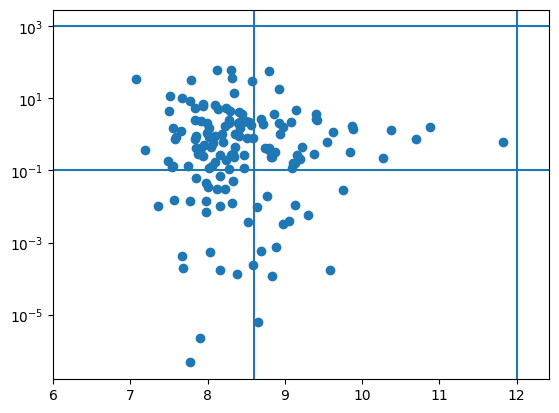

In [111]:
mask = (flags == True)
plt.figure()
plt.scatter(RUBIES_and_CEERS_table['median_mass'][mask], np.array(sfr_median_master) [mask])
plt.xlim(6,None)
plt.yscale('log')
plt.axhline(1e-1)
plt.axhline(1e3)
plt.axvline(8.6)
plt.axvline(12)
plt.show()

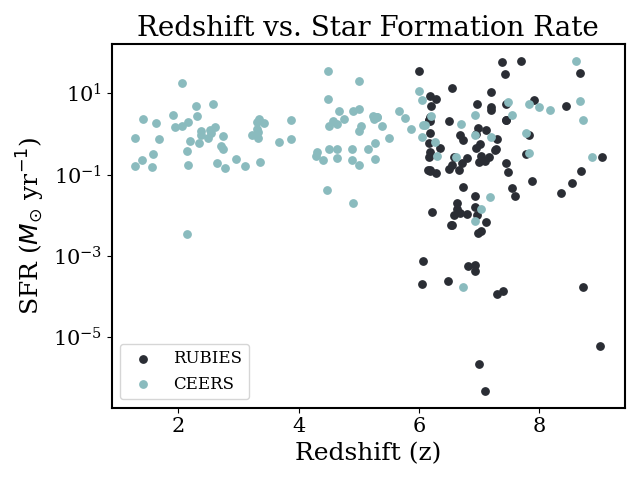

In [148]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table

# Assume the table is loaded and named RUBIES_and_CEERS_table, and that it has a 'catalog' column
RUBIES_and_CEERS_table = Table.read('MASTER_RUBIES_AND_CEERS_TABLE.fits')
sfr_median_master = RUBIES_and_CEERS_table['sfr_median']  # Assuming this column exists

# Define mask for flagged entries; assuming 'flags' is a boolean column in the table
mask = RUBIES_and_CEERS_table['flags']

# Define catalog colors (using the colorblind-friendly palette)
catalog_colors = {'RUBIES': '#2A2D34', 'CEERS': '#8ABBBE'}

# Enable interactive plotting in Jupyter
%matplotlib widget

# Ensure 'default' style is used if 'paper' is not available
plt.style.use('paper')
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['axes.linewidth'] = 1.5
plt.figure()

# Segment data by catalog and apply colors
for catalog in catalog_colors:
    cat_mask = (RUBIES_and_CEERS_table['catalog'][mask] == catalog)
    plt.scatter(RUBIES_and_CEERS_table['new_rubies_redshifts'][mask][cat_mask],
                sfr_median_master[mask][cat_mask],
                color=catalog_colors[catalog], s=28, label=catalog)

# Set scale, labels, title, and layout adjustments
plt.yscale('log')
plt.title('Redshift vs. Star Formation Rate')
plt.xlabel('Redshift (z)')
plt.ylabel(r'SFR ($M_{\odot}$ yr$^{-1}$)')
plt.legend()
plt.subplots_adjust(bottom=0.15)
plt.tight_layout()

# Save the plot before showing (to ensure it saves correctly)
plt.savefig('redshift_vs_sfr.pdf')

# Show the plot
plt.show()


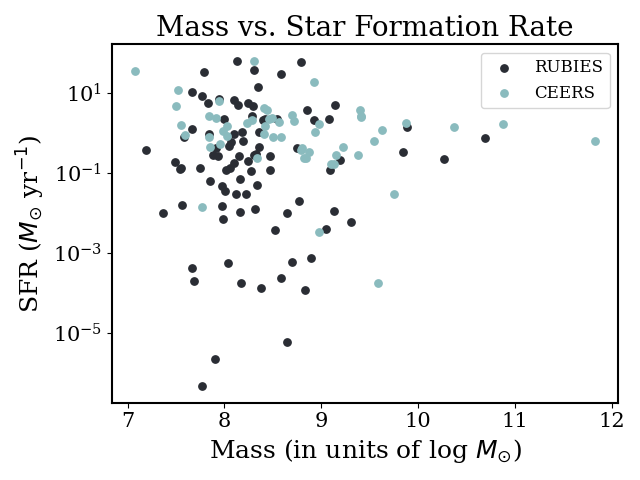

In [147]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table

# Assume the table is loaded and named RUBIES_and_CEERS_table, and that it has a 'catalog' column
RUBIES_and_CEERS_table = Table.read('MASTER_RUBIES_AND_CEERS_TABLE.fits')
sfr_median_master = RUBIES_and_CEERS_table['sfr_median']  # Assuming this column exists

# Define mask for flagged entries; assuming 'flags' is a boolean column in the table
mask = RUBIES_and_CEERS_table['flags']

# Define catalog colors (using the colorblind-friendly palette)
catalog_colors = {'RUBIES': '#2A2D34', 'CEERS': '#8ABBBE'}

# Enable interactive plotting in Jupyter
%matplotlib widget

# Ensure 'default' style is used if 'paper' is not available
plt.style.use('paper')
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['axes.linewidth'] = 1.5
plt.figure()

# Segment data by catalog and apply colors
for catalog in catalog_colors:
    cat_mask = (RUBIES_and_CEERS_table['catalog'][mask] == catalog)
    plt.scatter(RUBIES_and_CEERS_table['median_mass'][mask][cat_mask],
                sfr_median_master[mask][cat_mask],
                color=catalog_colors[catalog], s=28, label=catalog)

# Set scale, labels, title, and layout adjustments
plt.yscale('log')
plt.title('Mass vs. Star Formation Rate')
plt.xlabel('Mass (in units of log $M_{\odot}$)')
plt.ylabel(r'SFR ($M_{\odot}$ yr$^{-1}$)')
plt.legend()
plt.subplots_adjust(bottom=0.15)
plt.tight_layout()

# Save the plot before showing (to ensure it saves correctly)
plt.savefig('mass_vs_sfr.pdf')

# Show the plot
plt.show()


signal to noise
output of emcece: integrated fluxes
50th of flux / ((84th - 16th)/2)

if signal to noise <3, toss out ** 

- plot errorbars to data points of data, not just fill between of model
- print ratio, (16,50,84) to see if errorbar coversr above 1--> in that case is non-dust 
- have flag that checks ratio + upper 84th error
- redcued chi square to check if fits are decent (make sure to visually inspect each soruce in addition to reduced chi 
- plot mass
- sfr calculation (use halpha OR hbeta) - two diff sfr eqs

In [20]:
# RUBIES_and_CEERS_table['flux_intrinsic'] = flux_instrinsic_master
# RUBIES_and_CEERS_table['flux_error_corrected']= flux_error_master
# RUBIES_and_CEERS_table['dust_corrected']= flux_boolean
# RUBIES_and_CEERS_table['ratios']= ratios
# RUBIES_and_CEERS_table['which_ratio']= which_ratios_label
# RUBIES_and_CEERS_table['ratio_84th']= ratio_84_master

# #RUBIES_table['R VALUES']= R_master
# RUBIES_and_CEERS_table.write('MASTER_RUBIES_AND_CEERS_TABLE.fits',overwrite=True)